## 1- Load libraries: Basics + PyTorch + PyG (`pytorch_geometric`)


In this step, we import the main libraries that will be used throughout the GCN notebook.
We import libraries from three groups:

- **Basics**: for arrays, plotting, copying, and general utilities
- **PyTorch**: for tensors, neural networks, loss functions, and optimization
- **PyG (`pytorch_geometric`)**: for graph datasets, `Data` objects, graph layers such as `GCNConv`, pooling, transforms, and graph `DataLoader`

We also define:

- a **random seed** for reproducibility
- a **device** (`cpu` or `cuda`) so the model and data can later be moved to the same hardware

In [1]:
# =========================
# 1) Load libraries
# Basics + PyTorch + PyG
# =========================

# ---- basic python / plotting ----
import os
import copy
import numpy as np
import matplotlib.pyplot as plt

# ---- pytorch ----
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

# ---- pyg: graph data utilities ----
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.transforms import RandomNodeSplit

# ---- pyg: GNN layers / pooling ----
from torch_geometric.nn import GCNConv, global_mean_pool

# ---- optional: simple dataset utilities from pyg ----
# (useful for small demo datasets if needed later)
from torch_geometric.datasets import Planetoid, TUDataset

# ---- reproducibility ----
torch.manual_seed(42)
np.random.seed(42)

# ---- device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2- Load your graph Dataset D


For this notebook, we start with the **Cora** dataset.

- **Task type**: node-level supervised classification
- **Dataset form**: one big graph
- So here, `D` contains only **one graph**, which we call `data`

In PyG, this graph is stored as a **`Data` object**:

- `data.x` = NodeFeatures, shape: `[N_node, N_nodeFeatures]`
- `data.edge_index` = Edges, shape: `[2, N_edge]`
- `data.y` = target  
  - for **graph-level tasks**: usually shape `[N_graph]` or `[N_graph, N_target]`
  - for **node-level tasks**: usually shape `[N_node]` or `[N_node, N_target]`

For **Cora** specifically:

- `D = dataset`
- `data = dataset[0]`
- `data.x` contains one feature vector per node
- `data.edge_index` contains the graph connectivity
- `data.y` contains one class label per node

At this step, the goal is only to:

1. load `D`
2. extract the graph `data`
3. inspect the main dimensions of `x`, `edge_index`, and `y`

### FYI: What is the graph in Cora?

In **Cora**, there is only **one graph**.

This graph is a **citation network**:

- each **node** = one scientific paper
- each **edge** = a citation link between two papers

Each node also has:

- `x` = node feature vector, shape per node: `[N_nodeFeatures]`
- `y` = node label (paper class / topic)

So for the full graph:

- `data.x` has shape: `[N_node, N_nodeFeatures]`
- `data.edge_index` has shape: `[2, N_edge]`
- `data.y` has shape: `[N_node]`

This means:

- `D` contains only **one graph**
- the learning task is **node-level classification**
- the individual “samples” are the **nodes**, not separate graphs

So in Cora, we do **prediction on nodes inside one big graph**, rather than prediction on many separate small graphs.

In [25]:
# =========================
# 2) Load graph dataset D
# Here: Cora (one big graph)
# =========================

from torch_geometric.datasets import Planetoid

# Load dataset D
dataset = Planetoid(root="data/Planetoid", name="Cora")

# Since Cora is one big graph, D has only one graph
data = dataset[0]

# Basic dataset info
print("Dataset:", dataset)
print("Number of graphs in D:", len(dataset))
print()

# Inspect the PyG Data object
print(data)
print()

# Main tensors
print("data.x shape          :", data.x.shape)          # [N_node, N_nodeFeatures]
print("data.edge_index shape :", data.edge_index.shape) # [2, N_edge]
print("data.y shape          :", data.y.shape)          # [N_node]
print()

# Useful summary numbers
print("Number of nodes       :", data.num_nodes)
print("Number of node features:", dataset.num_features)
print("Number of edges       :", data.num_edges)
print("Number of classes     :", dataset.num_classes)

# Optional: move later when needed
# data = data.to(device)

Dataset: Cora()
Number of graphs in D: 1

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

data.x shape          : torch.Size([2708, 1433])
data.edge_index shape : torch.Size([2, 10556])
data.y shape          : torch.Size([2708])

Number of nodes       : 2708
Number of node features: 1433
Number of edges       : 10556
Number of classes     : 7


In [16]:
# just for you to see the shapes again cleany inside the data object!
data.x.shape,data.edge_index.shape, data.y.shape

(torch.Size([2708, 1433]), torch.Size([2, 10556]), torch.Size([2708]))

## 3- Now set up the training / validation / testing split


This step depends on the task type.

### Case A) If `D` has many graphs
Here, each graph is one sample.

- Split the dataset into:
  - `train_dataset`
  - `val_dataset`
  - `test_dataset`

- Then load each split using PyG `DataLoader`

In this case, PyG will batch multiple **`Data` objects** automatically into one mini-batch.

So the training loop will usually look like:

- one batch = several graphs
- each graph has its own:
  - `x`
  - `edge_index`
  - `y`
- PyG also creates a `batch` vector to tell which nodes belong to which graph

---

### Case B) If `D` has one big graph for node classification / regression
Here, we keep only **one** `Data` object:

- `data.x` = NodeFeatures, shape: `[N_node, N_nodeFeatures]`
- `data.edge_index` = Edges, shape: `[2, N_edge]`
- `data.y` = node targets, shape: `[N_node]` or `[N_node, N_target]`

In this case, we do **not** split the graph into separate graphs.

Instead, we need:

- `data.train_mask`
- `data.val_mask`
- `data.test_mask`

Each mask has shape:

- `[N_node]`

and each element is `True` or `False`, telling whether that node belongs to the train, validation, or test set.

If these masks are not already provided by the dataset, they can be created using:

- `RandomNodeSplit` from PyG

For this notebook with **Cora**:

- `D` has only **one graph**
- so we follow **case B**
- we keep one `Data` object and use node masks
- therefore, in this notebook step, there is **no graph `DataLoader`** as is not needed. Masks will do the job

In [27]:
# =========================
# 3) Set up train / val / test split
# Case here: one big graph (Cora)
# =========================

# For Cora, we keep one Data object: data
# Standard Planetoid-style datasets often already include masks
has_train_mask = hasattr(data, "train_mask")
has_val_mask = hasattr(data, "val_mask")
has_test_mask = hasattr(data, "test_mask")

print("Has train_mask:", has_train_mask)
print("Has val_mask  :", has_val_mask)
print("Has test_mask :", has_test_mask)
print()

# If masks are missing, create them with RandomNodeSplit
if not (has_train_mask and has_val_mask and has_test_mask):
    split_transform = RandomNodeSplit(
        split="train_rest",   # simple random split
        num_val=0.1,          # 10% of nodes for validation
        num_test=0.2          # 20% of nodes for test
    )
    data = split_transform(data)


# Inspect mask shapes
print("train_mask shape:", data.train_mask.shape)
print("val_mask shape  :", data.val_mask.shape)
print("test_mask shape :", data.test_mask.shape)
print()

# Count how many nodes are in each split
print("Number of train nodes:", int(data.train_mask.sum()))
print("Number of val nodes  :", int(data.val_mask.sum()))
print("Number of test nodes :", int(data.test_mask.sum()))
print()

# Optional: check that every node belongs to exactly one split
mask_sum = data.train_mask.int() + data.val_mask.int() + data.test_mask.int()
print("All nodes assigned once:", bool((mask_sum == 1).all()))

Has train_mask: True
Has val_mask  : True
Has test_mask : True

train_mask shape: torch.Size([2708])
val_mask shape  : torch.Size([2708])
test_mask shape : torch.Size([2708])

Number of train nodes: 140
Number of val nodes  : 500
Number of test nodes : 1000

All nodes assigned once: False


Note that Cora already had train/val/test masks,check yourself by running data.train_mask before above block

## 4- Build the GCN neural network using PyG GCN built in module


A GCN model has **two main parts**:

### Step A) Define the GCN layers as a module `[GCN]`
This part updates the node features by passing messages through the graph.

- Input:  
  `x` = node feature matrix, shape: `[N_node, N_nodeFeatures]`
- Graph structure:  
  `edge_index` = edges, shape: `[2, N_edge]`
- Output:  
  `x'` = updated node features, shape: `[N_node, N_hidden]` or `[N_node, N_outGCN]`

A simple stacked GCN looks like:

`x  -> [GCNConv -> ReLU -> Dropout] -> ... -> [GCNConv] -> x'`

So the `[GCN]` module learns a new feature vector for each node, while keeping the graph structure through `edge_index`.

---

In [101]:
# =========================
# 4) Build the GCN network
# GCN layers + task heads
# =========================

# -------------------------------------------------
# A) GCN layers module: x -> x'
# -------------------------------------------------
class GCN(nn.Module):
    """
    GCN backbone.

    Input
    -----
    x          : [N_node, in_channels]
    edge_index : [2, N_edge]

    Output
    ------
    x_prime    : [N_node, gcn_out_channels]
    """

    def __init__(self, in_channels, hidden_channels, gcn_out_channels, n_gcn_layers=2, dropout=0.5):
        super().__init__()

        assert n_gcn_layers >= 1, "Use at least 2 GCN layers."

        self.dropout = dropout
        self.convs = nn.ModuleList()

        # first GCN layer, note that we imported standard GCN layer as "GCNConv" from torch_geometric.nn
        self.convs.append(GCNConv(in_channels, hidden_channels))

        # middle GCN layers
        for _ in range(n_gcn_layers - 1):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))

        # last GCN layer
        self.convs.append(GCNConv(hidden_channels, gcn_out_channels))


    # comes handy when want to tune hyper parameters
    def reset_parameters(self):
        """Reset all GCNConv layer parameters."""
        for conv in self.convs:
            conv.reset_parameters()

    # now defiining the forward path of our [GCN] Module
    def forward(self, x, edge_index):
        # all but last layer: GCN -> ReLU -> Dropout
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # last layer gives final node representation x'
        x = self.convs[-1](x, edge_index)
        return x



### Step B) Define the task head as a module `[Task Head]`

The task head depends on the prediction level.

#### For node-level tasks
(one output per node: classification, regression, embedding, etc.)

`x' -> [Linear layer] -> out -> ŷ_v`

- Input: `x'`, shape: `[N_node, N_outGCN]`
- Output: `out`, shape: `[N_node, N_target]`

Each row in the output corresponds to one node.

---

#### For graph-level tasks
(one output per graph: classification, regression, embedding, etc.)

`x' -> [GlobalMeanPool(batch)] -> graph_embedding -> [Linear layer] -> out -> Ŷ`

- Input: `x'`, shape: `[N_totalNodesInBatch, N_outGCN]`
- `batch` tells which node belongs to which graph
- After pooling:  
  `graph_embedding`, shape: `[N_graphInBatch, N_outGCN]`
- Output:  
  `out`, shape: `[N_graphInBatch, N_target]`

So:

- **node task** = predict from each node representation directly
- **graph task** = first pool node representations into one graph representation, then predict

In [102]:
# -------------------------------------------------
# B1) Task head for node-level tasks
# x' -> Linear -> out -> y_hat_v
# -------------------------------------------------
class NodeTaskHead(nn.Module):
    """
    Node-level task head.

    Input
    -----
    x_prime : [N_node, gcn_out_channels]

    Output
    ------
    out     : [N_node, out_channels]
    """

    def __init__(self, gcn_out_channels, out_channels):
        super().__init__()
        self.linear = nn.Linear(gcn_out_channels, out_channels)

    def reset_parameters(self):
        """Reset linear layer parameters."""
        self.linear.reset_parameters()

    def forward(self, x_prime):
        out = self.linear(x_prime)
        return out


In case we had graph level task it would have been like bellow. We will cover this in another notebook

In [40]:
# # -------------------------------------------------
# # B2) Task head for graph-level tasks
# # x' -> GlobalMeanPool -> Linear -> out -> Y_hat
# # -------------------------------------------------
# class GraphTaskHead(nn.Module):
#     """
#     Graph-level task head.

#     Input
#     -----
#     x_prime : [N_totalNodesInBatch, gcn_out_channels]
#     batch   : [N_totalNodesInBatch]

#     Output
#     ------
#     out     : [N_graphInBatch, out_channels]
#     """

#     def __init__(self, gcn_out_channels, out_channels):
#         super().__init__()
#         self.linear = nn.Linear(gcn_out_channels, out_channels)

#     def forward(self, x_prime, batch):
#         graph_embedding = global_mean_pool(x_prime, batch)  # [N_graphInBatch, gcn_out_channels]
#         out = self.linear(graph_embedding)
#         return out


# # -------------------------------------------------
# # Optional full model for graph-level tasks
# # x -> [GCN] -> x' -> [GraphTaskHead] -> out
# # -------------------------------------------------
# class GCN_GraphModel(nn.Module):
#     def __init__(self, in_channels, hidden_channels, gcn_out_channels, out_channels,
#                  n_gcn_layers=2, dropout=0.5):
#         super().__init__()
#         self.gcn = GCN(
#             in_channels=in_channels,
#             hidden_channels=hidden_channels,
#             gcn_out_channels=gcn_out_channels,
#             n_gcn_layers=n_gcn_layers,
#             dropout=dropout,
#         )
#         self.head = GraphTaskHead(
#             gcn_out_channels=gcn_out_channels,
#             out_channels=out_channels,
#         )

#     def forward(self, x, edge_index, batch):
#         x_prime = self.gcn(x, edge_index)
#         out = self.head(x_prime, batch)
#         return out

**now putting all parts together**:  x -> [GCN] -> x' -> [NodeTaskHead] -> out

In [104]:
# -------------------------------------------------
#  full model for node-level tasks
# x -> [GCN] -> x' -> [NodeTaskHead] -> out
# -------------------------------------------------
class GCN_NodeModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, gcn_out_channels, out_channels,
                 n_gcn_layers=2, dropout=0.5):
        super().__init__()
        self.gcn = GCN(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            gcn_out_channels=gcn_out_channels,
            n_gcn_layers=n_gcn_layers,
            dropout=dropout,
        )
        self.head = NodeTaskHead(
            gcn_out_channels=gcn_out_channels,
            out_channels=out_channels,
        )
    def reset_parameters(self):
        """Reset both the GCN backbone and the node task head."""
        self.gcn.reset_parameters()
        self.head.reset_parameters()
        
        

    def forward(self, x, edge_index):
        x_prime = self.gcn(x, edge_index) # first GCN module
        out = self.head(x_prime)          # then the task head
        return out     # and the output!




# -------------------------------------------------
# Example:model for Cora node classification
# -------------------------------------------------
node_model = GCN_NodeModel(
    in_channels=dataset.num_features,   # N_nodeFeatures
    hidden_channels=32,                 # hidden size inside GCN
    gcn_out_channels=16,                # size of x'
    out_channels=dataset.num_classes,   # number of classes
    n_gcn_layers=2,
    dropout=0.3,
).to(device)

print(node_model)

GCN_NodeModel(
  (gcn): GCN(
    (convs): ModuleList(
      (0): GCNConv(1433, 32)
      (1): GCNConv(32, 32)
      (2): GCNConv(32, 16)
    )
  )
  (head): NodeTaskHead(
    (linear): Linear(in_features=16, out_features=7, bias=True)
  )
)


## 5- Define a proper loss function based on `out` and `y`


At this step, the model already gives an output:

- `out` = raw model output (**logits** for classification), shape:
  - node-level: `[N_node, N_target]`
  - graph-level: `[N_graphInBatch, N_target]`

The target is:

- `y`, shape:
  - node-level: `[N_node]` or `[N_node, N_target]`
  - graph-level: `[N_graphInBatch]` or `[N_graphInBatch, N_target]`

### A) Choose the task loss

#### a- If the target is continuous
Use:

- `nn.MSELoss()` or
- `nn.L1Loss()`

Examples:
- node regression
- graph regression
- embedding reconstruction targets

---

#### b- If the target is categorical
Use:

- `nn.CrossEntropyLoss()`

Important:

- feed **raw logits** directly to `CrossEntropyLoss`
- do **not** apply `softmax` before the loss

Expected shapes for classification:

- `out`: `[N_sample, N_class]`
- `y`: `[N_sample]`  
  where each value in `y` is a class index

---

### B) Where to calculate the loss

#### i- For node-level tasks
Only calculate the loss on the selected nodes, usually:

- `train_mask` during training
- `val_mask` during validation
- `test_mask` during testing

So we compare:

- `out[mask]`
- `y[mask]`

---

#### ii- For graph-level tasks
Calculate the loss directly on the graph outputs:

- `out`
- `y`

because each row of `out` already corresponds to one graph.

---

### C) Add regularization

To reduce overfitting, the total loss can include:

- the main task loss
- plus one or more regularization terms

A common form is:

`total_loss = task_loss + lambda_reg * reg_loss`

Examples of regularization:

- L2 penalty on weights
- dropout inside the model
- weight decay in the optimizer

---

So in general:

- choose a task loss that matches the target type
- compute it on the correct samples
- then add any extra regularization terms
- the final loss is the sum of all relevant parts

For this project, the task is node classification on Cora, so the target is categorical and we use `nn.CrossEntropyLoss()` on the selected nodes only, usually `out[data.train_mask]` and `data.y[data.train_mask]`.

In [105]:
# =========================
# 5) Define the loss
# task loss + optional regularization
# =========================

# -------------------------------------------------
# A) Choose the main task loss
# -------------------------------------------------

# For categorical targets:
criterion_cls = nn.CrossEntropyLoss()

# For continuous targets:
criterion_mse = nn.MSELoss()
criterion_l1 = nn.L1Loss()


# -------------------------------------------------
# B1) Node-level loss
# use only the selected nodes, e.g. train_mask
# -------------------------------------------------
def compute_node_loss(out, y, mask, task_type="classification",
                      criterion_reg=None, lambda_reg=0.0, model=None):
    """
    out  : [N_node, N_target]   raw model output
    y    : [N_node] or [N_node, N_target]
    mask : [N_node] boolean mask

    Returns
    -------
    total_loss, task_loss, reg_loss
    """

    # select only the masked nodes
    out_masked = out[mask]
    y_masked = y[mask]

    # main task loss
    if task_type == "classification":
        task_loss = criterion_cls(out_masked, y_masked)

    elif task_type == "regression_mse":
        task_loss = criterion_mse(out_masked, y_masked)

    elif task_type == "regression_l1":
        task_loss = criterion_l1(out_masked, y_masked)

    else:
        raise ValueError("Unknown task_type.")

    # optional extra regularization term
    reg_loss = torch.tensor(0.0, device=out.device)

    if (criterion_reg is not None) and (lambda_reg > 0.0) and (model is not None):
        reg_loss = criterion_reg(model)

    total_loss = task_loss + lambda_reg * reg_loss
    return total_loss, task_loss, reg_loss

# -------------------------------------------------
# FYI simple L2 regularization on parameters
# -------------------------------------------------
def l2_regularization(model):
    reg = 0.0
    for param in model.parameters():
        reg = reg + torch.sum(param ** 2)
    return reg


# -------------------------------------------------
#  Example usage for Cora node classification
# -------------------------------------------------
# out = node_model(data.x.to(device), data.edge_index.to(device))
# y = data.y.to(device)
# mask = data.train_mask.to(device)

# total_loss, task_loss, reg_loss = compute_node_loss(
#     out=out,
#     y=y,
#     mask=mask,
#     task_type="classification",
#     criterion_reg=l2_regularization,   # optional
#     lambda_reg=1e-4,                   # optional
#     model=node_model                   # optional
# )
#
# print("total_loss:", float(total_loss))
# print("task_loss :", float(task_loss))
# print("reg_loss  :", float(reg_loss))

In cased we had a graph level loos we could use bellow:

In [106]:

# # -------------------------------------------------
# # B2) Graph-level loss
# # use graph outputs directly
# # -------------------------------------------------
# def compute_graph_loss(out, y, task_type="classification",
#                        criterion_reg=None, lambda_reg=0.0, model=None):
#     """
#     out : [N_graphInBatch, N_target]
#     y   : [N_graphInBatch] or [N_graphInBatch, N_target]

#     Returns
#     -------
#     total_loss, task_loss, reg_loss
#     """

#     # main task loss
#     if task_type == "classification":
#         task_loss = criterion_cls(out, y)

#     elif task_type == "regression_mse":
#         task_loss = criterion_mse(out, y)

#     elif task_type == "regression_l1":
#         task_loss = criterion_l1(out, y)

#     else:
#         raise ValueError("Unknown task_type.")

#     # optional extra regularization term
#     reg_loss = torch.tensor(0.0, device=out.device)

#     if (criterion_reg is not None) and (lambda_reg > 0.0) and (model is not None):
#         reg_loss = criterion_reg(model)

#     total_loss = task_loss + lambda_reg * reg_loss
#     return total_loss, task_loss, reg_loss


## 6- Define the train and validation / test functions


These functions are usually **standard**.

Their main job is to:

- run the model forward
- calculate the loss
- update the parameters during training
- report performance on training / validation / test data

---

### A) For node-level tasks on one big graph
Here, we keep one `Data` object:

- `x`, shape: `[N_node, N_nodeFeatures]`
- `edge_index`, shape: `[2, N_edge]`
- `y`, shape: `[N_node]` or `[N_node, N_target]`

The model gives:

- `out`, shape: `[N_node, N_target]`

For training / validation / testing, we use masks:

- `train_mask`, shape: `[N_node]`
- `val_mask`, shape: `[N_node]`
- `test_mask`, shape: `[N_node]`

So:

- during **training**, compute loss only on `out[train_mask]`
- during **validation**, compute loss only on `out[val_mask]`
- during **testing**, compute loss only on `out[test_mask]`

Even though the forward pass uses the **whole graph**, the loss is calculated only on the selected nodes.

---

### B) For graph-level tasks with many graphs
Here, the data comes from a PyG `DataLoader`.

Each batch contains a set of graphs, with:

- `x` = all node features in the batch
- `edge_index` = all edges in the batch
- `batch` = graph assignment vector for nodes
- `y` = graph targets

The model gives:

- `out`, shape: `[N_graphInBatch, N_target]`

So:

- during training / validation / testing, compute the loss directly on:
  - `out`
  - `y`

because each row already corresponds to one graph.

---

### C) Train vs evaluation mode

In general:

- **train function**:
  - use `model.train()`
  - enable gradient computation
  - do:
    - `optimizer.zero_grad()`
    - forward pass
    - loss
    - `loss.backward()`
    - `optimizer.step()`

- **validation / test function**:
  - use `model.eval()`
  - do not update parameters
  - use `torch.no_grad()`

These functions are usually the same structure for many models.  
The main difference is only **how the loss is selected**:
- by **mask** for node-level tasks
- by **batch of graphs** for graph-level tasks

In [107]:
# =========================
# 6) Define train / validate / test functions
# Standard versions for:
#   A) node-level tasks on one big graph
#   B) graph-level tasks with PyG DataLoader
# =========================

import torch


# -------------------------------------------------
# helper: accuracy for classification
# -------------------------------------------------
def classification_accuracy(logits, y_true):
    """
    logits : [N_sample, N_class]
    y_true : [N_sample]
    """
    y_pred = logits.argmax(dim=1)
    acc = (y_pred == y_true).float().mean()
    return acc.item()


# =================================================
# A) NODE-LEVEL TASKS
# one big graph + masks
# =================================================
def train_node_epoch(model, data, optimizer, criterion, device):
    """
    Train for one epoch on a single big graph.

    data.x          : [N_node, N_nodeFeatures]
    data.edge_index : [2, N_edge]
    data.y          : [N_node]
    data.train_mask : [N_node]
    """
    model.train()

    # move data to device
    x = data.x.to(device)
    edge_index = data.edge_index.to(device)
    y = data.y.to(device)
    train_mask = data.train_mask.to(device)

    # standard training steps
    optimizer.zero_grad()
    out = model(x, edge_index)                    # [N_node, N_class]
    loss = criterion(out[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()

    # training accuracy on masked nodes
    acc = classification_accuracy(out[train_mask], y[train_mask])

    return loss.item(), acc


@torch.no_grad()
def eval_node(model, data, mask_name, criterion, device):
    """
    Evaluate on val or test nodes of one big graph.

    mask_name : "train_mask", "val_mask", or "test_mask"
    """
    model.eval()

    # move data to device
    x = data.x.to(device)
    edge_index = data.edge_index.to(device)
    y = data.y.to(device)
    mask = getattr(data, mask_name).to(device)

    out = model(x, edge_index)                    # [N_node, N_class]
    loss = criterion(out[mask], y[mask])
    acc = classification_accuracy(out[mask], y[mask])

    return loss.item(), acc

# =================================================
# Example for this project: Cora node classification
# =================================================
# assumes:
#   - node_model already exists
#   - criterion_cls = nn.CrossEntropyLoss()
#   - optimizer = Adam(node_model.parameters(), lr=0.01, weight_decay=5e-4)

optimizer = Adam(node_model.parameters(), lr=0.01, weight_decay=5e-4)

# train_loss, train_acc = train_node_epoch(
#     model=node_model,
#     data=data,
#     optimizer=optimizer,
#     criterion=criterion_cls,
#     device=device,
# )

# val_loss, val_acc = eval_node(
#     model=node_model,
#     data=data,
#     mask_name="val_mask",
#     criterion=criterion_cls,
#     device=device,
# )

# test_loss, test_acc = eval_node(
#     model=node_model,
#     data=data,
#     mask_name="test_mask",
#     criterion=criterion_cls,
#     device=device,
# )

# print(f"Train -> loss: {train_loss:.4f}, acc: {train_acc:.4f}")
# print(f"Val   -> loss: {val_loss:.4f}, acc: {val_acc:.4f}")
# print(f"Test  -> loss: {test_loss:.4f}, acc: {test_acc:.4f}")

In case of graph level task:

In [108]:

# # =================================================
# # B) GRAPH-LEVEL TASKS
# # many graphs + PyG DataLoader
# # =================================================
# def train_graph_epoch(model, loader, optimizer, criterion, device):
#     """
#     Train for one epoch on batched graphs from a PyG DataLoader.

#     batch.x          : [N_totalNodesInBatch, N_nodeFeatures]
#     batch.edge_index : [2, N_edgeInBatch]
#     batch.batch      : [N_totalNodesInBatch]
#     batch.y          : [N_graphInBatch]
#     """
#     model.train()

#     total_loss = 0.0
#     total_correct = 0
#     total_graphs = 0

#     for batch in loader:
#         batch = batch.to(device)

#         optimizer.zero_grad()
#         out = model(batch.x, batch.edge_index, batch.batch)   # [N_graphInBatch, N_class]
#         loss = criterion(out, batch.y)
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item() * batch.num_graphs
#         total_correct += (out.argmax(dim=1) == batch.y).sum().item()
#         total_graphs += batch.num_graphs

#     avg_loss = total_loss / total_graphs
#     avg_acc = total_correct / total_graphs

#     return avg_loss, avg_acc


# @torch.no_grad()
# def eval_graph(model, loader, criterion, device):
#     """
#     Evaluate on batched graphs from a PyG DataLoader.
#     """
#     model.eval()

#     total_loss = 0.0
#     total_correct = 0
#     total_graphs = 0

#     for batch in loader:
#         batch = batch.to(device)

#         out = model(batch.x, batch.edge_index, batch.batch)   # [N_graphInBatch, N_class]
#         loss = criterion(out, batch.y)

#         total_loss += loss.item() * batch.num_graphs
#         total_correct += (out.argmax(dim=1) == batch.y).sum().item()
#         total_graphs += batch.num_graphs

#     avg_loss = total_loss / total_graphs
#     avg_acc = total_correct / total_graphs

#     return avg_loss, avg_acc


## 7- Define training and run the training


This step is the same as in standard deep learning workflows.

For each epoch:

- run the **train** function on the training data
- then run the **evaluation** function on:
  - the training split
  - the validation split

This lets us track whether the model is:

- learning well on the training data
- generalizing to unseen validation nodes / graphs
- starting to overfit

During training, we usually save the **best model**, based on the **validation loss** or **validation accuracy**.

At the end:

- load the best saved model
- evaluate it on the test set
- optionally plot:
  - training loss curve
  - validation loss curve

So this step mainly does three things:

1. train for many epochs
2. track performance across epochs
3. reload the best model before final testing


Important:

- the **validation set** is used for model selection
- the **test set** is used only once at the end for final reporting

Epoch 001 | train_loss=1.8811, train_acc=0.4071 | val_loss=1.8911, val_acc=0.4140
Epoch 020 | train_loss=0.0088, train_acc=1.0000 | val_loss=1.1162, val_acc=0.7600

Best model came from epoch 14 with val_loss = 0.7301
Final Train -> loss: 0.0682, acc: 0.9929
Final Val   -> loss: 0.7301, acc: 0.7860
Final Test  -> loss: 0.6757, acc: 0.7970


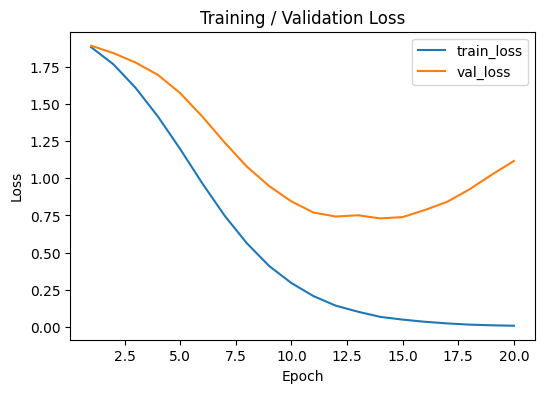

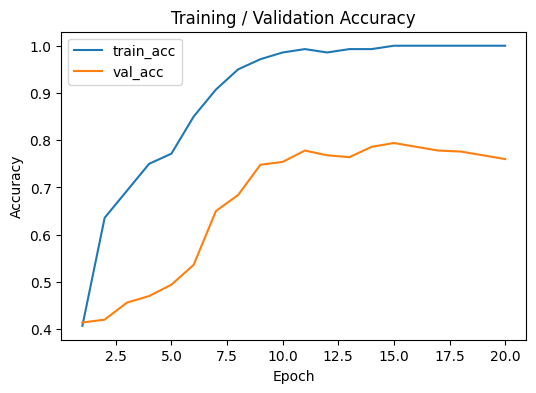

In [112]:
# =========================
# 7) Define training loop and run training
# Example here: Cora node classification
# =========================

import copy
import matplotlib.pyplot as plt
from torch.optim import Adam


# -------------------------------------------------
# optimizer and training settings
# -------------------------------------------------
optimizer = Adam(node_model.parameters(), lr=0.01, weight_decay=5e-4)
n_epochs = 20

# -------------------------------------------------
# history containers
# -------------------------------------------------
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

# best model tracking
best_val_loss = float("inf")
best_epoch = -1
best_state = None

# -------------------------------------------------
# main training loop
# -------------------------------------------------

node_model.reset_parameters() #making sure eveyrhting is fresh

for epoch in range(1, n_epochs + 1):

    # 1) train for one epoch on training nodes
    train_step_loss, train_step_acc = train_node_epoch(
        model=node_model,
        data=data,
        optimizer=optimizer,
        criterion=criterion_cls,
        device=device,
    )

    # 2) evaluate current model on train and validation splits
    train_loss, train_acc = eval_node(
        model=node_model,
        data=data,
        mask_name="train_mask",
        criterion=criterion_cls,
        device=device,
    )

    val_loss, val_acc = eval_node(
        model=node_model,
        data=data,
        mask_name="val_mask",
        criterion=criterion_cls,
        device=device,
    )

    # 3) store history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # 4) save best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = copy.deepcopy(node_model.state_dict())

    # 5) print progress every few epochs
    if epoch == 1 or epoch % 20 == 0 or epoch == n_epochs:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

# -------------------------------------------------
# load best model
# -------------------------------------------------
if best_state is not None:
    node_model.load_state_dict(best_state)

print()
print(f"Best model came from epoch {best_epoch} with val_loss = {best_val_loss:.4f}")

# -------------------------------------------------
# final evaluation with best model
# -------------------------------------------------
train_loss, train_acc = eval_node(
    model=node_model,
    data=data,
    mask_name="train_mask",
    criterion=criterion_cls,
    device=device,
)

val_loss, val_acc = eval_node(
    model=node_model,
    data=data,
    mask_name="val_mask",
    criterion=criterion_cls,
    device=device,
)

test_loss, test_acc = eval_node(
    model=node_model,
    data=data,
    mask_name="test_mask",
    criterion=criterion_cls,
    device=device,
)

print(f"Final Train -> loss: {train_loss:.4f}, acc: {train_acc:.4f}")
print(f"Final Val   -> loss: {val_loss:.4f}, acc: {val_acc:.4f}")
print(f"Final Test  -> loss: {test_loss:.4f}, acc: {test_acc:.4f}")

# -------------------------------------------------
# optional: plot training / validation curves
# -------------------------------------------------
epochs = range(1, n_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="train_acc")
plt.plot(epochs, history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training / Validation Accuracy")
plt.legend()
plt.show()